# 04 — SALT3 Init Deep Debug

Goal: find **why the new init (`videberta_salt_init_v5_globalmap_freqbias`) starts at ~7.1 step-0 MLM loss** (the
Vietnamese unigram-entropy floor) instead of *beating* it with context.

It dissects the loss into components, sweeps the decoder scale, audits embedding/decoder **geometry vs the NeoBERT
manifold**, runs a **ground-truth leave-one-out** test of the projection math, and (best-effort) loads the old
`SALT` folder for a side-by-side / component-swap comparison.

**How to read it:** each section prints a verdict line; the final cell collects them. The decisive questions are —
(1) is the loss the *bias floor* (decoder contributes nothing)? (2) does the decoder *help or hurt* as you scale it?
(3) does the projection reconstruct **known** anchor points? (4) does the old init actually do better here, and if so
which component carries the gap?

**Harness upgrades:** frozen held-out eval set (A.1), rung-1 **donor-space soundness** (F — donor geometry vs FastText-vi, no projection), and the **init bake-off** table (I) that feeds the init decision gate.

In [1]:
%%capture
!pip install -U transformers accelerate datasets safetensors sentencepiece tokenizers fasttext-wheel matplotlib pandas scikit-learn xformers einops protobuf

In [2]:
import sys, gc, math
from pathlib import Path
import numpy as np, pandas as pd, torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

try:
    from google.colab import drive; drive.mount('/content/drive')
except Exception as e:
    print('Drive mount skipped:', e)

PROJECT_ROOT = Path('/content/drive/MyDrive/SALT3')
DRIVE_ROOT   = PROJECT_ROOT.parent                 # /content/drive/MyDrive — old SALT folder lives here
sys.path.insert(0, str(PROJECT_ROOT / 'code'))
sys.path.insert(0, '/content')

import importlib, salt3_common as sc, salt3_diagnostics as dx, salt3_init_forensics as fx
importlib.reload(sc); importlib.reload(dx); importlib.reload(fx)
from salt3_common import (configure_environment, set_seed, load_model_safe,
                          extract_embedding_weight, fit_embedding_to_decoder_map)
from transformers import AutoModel, AutoModelForMaskedLM, AutoTokenizer

configure_environment(); set_seed(42)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', DEVICE)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cuda


## Config — paths & toggles

In [3]:
# ── New init under test ──────────────────────────────────────────────────────
NEW_INIT_NAME = 'videberta_salt_init_v5_globalmap_freqbias'
NEW_INIT_DIR  = PROJECT_ROOT / 'init' / NEW_INIT_NAME
NEW_MODEL_DIR = NEW_INIT_DIR / 'model'
ANCHOR_FILES  = ['verified_shared_anchors.csv', 'shared_numbers.csv', 'verified_translation_pairs.csv']

# ── Base models the init was built from ──────────────────────────────────────
SOURCE_MODEL_ID = 'chandar-lab/NeoBERT'        # NeoBERT (source space)
TARGET_MODEL_ID = 'Fsoft-AIC/videberta-base'   # ViDeBERTa (donor embeddings)

# ── Old SALT init (best-effort compare; layout unknown — loader will search) ──
OLD_SALT_ROOT = DRIVE_ROOT / 'SALT'            # everything in the folder root, per your note

# ── Toggles (heavy steps off by default) ─────────────────────────────────────
RUN_LOO          = True    # leave-one-out projection test (FastText shared with section F)
RUN_OLD_COMPARE  = True    # load old SALT folder and compare
N_STREAM_EVAL    = 0       # extra CulturaX-vi sentences for the loss harness (0 = fixed set only)
FASTTEXT_BIN     = str(NEW_INIT_DIR / 'cc.vi.300.bin')
FIXED_EVAL_FILE  = PROJECT_ROOT / 'eval' / 'fixed_eval_sentences.json'   # frozen held-out eval set
BAKEOFF_EXTRA    = []      # extra init candidates for section I: [(name, model_dir_str)], e.g.
# BAKEOFF_EXTRA = [('videberta_procrustes_v6', str(PROJECT_ROOT/'init'/'videberta_procrustes_init_v6'/'model')),
#                  ('phobert_procrustes_v6',   str(PROJECT_ROOT/'init'/'phobert_procrustes_init_v6'/'model'))]
print('New init dir :', NEW_INIT_DIR)
print('Old SALT root:', OLD_SALT_ROOT, '(exists:', OLD_SALT_ROOT.exists(), ')')

New init dir : /content/drive/MyDrive/SALT3/init/videberta_salt_init_v5_globalmap_freqbias
Old SALT root: /content/drive/MyDrive/SALT (exists: True )


## A. Load the new init + base models

In [4]:
import os
if os.environ.get('HF_TOKEN'):
    from huggingface_hub import login
    login(token=os.environ['HF_TOKEN'])

### A.1 Frozen held-out eval set (one-time build)
~500 CulturaX-vi snippets + doc-id manifest saved to Drive **once**. Every decisive measurement uses this file so
numbers stay comparable across sessions, and CPT data preparation must exclude its doc ids (held-out guarantee).


In [5]:
# Frozen held-out eval set — built ONCE, then shared by every decisive measurement.
# CPT data prep must exclude the doc ids stored in this file's manifest.
if not FIXED_EVAL_FILE.exists():
    fx.build_frozen_eval_file(FIXED_EVAL_FILE, n_sentences=500)
else:
    print('frozen eval set present:', FIXED_EVAL_FILE)


README.md:   0%|          | 0.00/32.6k [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/90 [00:00<?, ?it/s]

frozen eval set saved -> /content/drive/MyDrive/SALT3/eval/fixed_eval_sentences.json (500 snippets, doc ids in manifest)


In [6]:
# New init (the artifact under investigation)
new_model = load_model_safe(NEW_MODEL_DIR, model_cls=AutoModelForMaskedLM, device=DEVICE).eval()
new_tok   = AutoTokenizer.from_pretrained(NEW_MODEL_DIR, trust_remote_code=True)
new_emb   = extract_embedding_weight(new_model).float().cpu()
new_dec   = new_model.decoder.weight.detach().float().cpu()
new_bias  = new_model.decoder.bias.detach().float().cpu()
VOCAB = new_model.config.vocab_size
print(f'new init: vocab={VOCAB}  emb{tuple(new_emb.shape)}  dec{tuple(new_dec.shape)}')

# Base models (for geometry references)
neo_model = AutoModelForMaskedLM.from_pretrained(SOURCE_MODEL_ID, trust_remote_code=True).eval()
neo_emb   = extract_embedding_weight(neo_model).float().cpu()
neo_dec   = neo_model.decoder.weight.detach().float().cpu()
neo_tok   = AutoTokenizer.from_pretrained(SOURCE_MODEL_ID, trust_remote_code=True)

vide_model = AutoModel.from_pretrained(TARGET_MODEL_ID, trust_remote_code=True).eval()
vide_emb   = extract_embedding_weight(vide_model).float().cpu()
vide_tok   = AutoTokenizer.from_pretrained(TARGET_MODEL_ID, trust_remote_code=True)
print(f'NeoBERT emb {tuple(neo_emb.shape)} | ViDeBERTa emb {tuple(vide_emb.shape)}')

# String-based row alignment (robust to vocab reordering)
new_vocab, neo_vocab, vide_vocab = new_tok.get_vocab(), neo_tok.get_vocab(), vide_tok.get_vocab()
new_to_vide = {nid: vide_vocab[t] for t, nid in new_vocab.items() if t in vide_vocab}
print(f'new tokens also in ViDeBERTa: {len(new_to_vide)}/{VOCAB}')

# Master anchor map = union of the saved anchor CSVs (cols videberta_token/neobert_token)
def _load_anchor_map(init_dir, files):
    frames = []
    for fn in files:
        p = init_dir / fn
        if p.exists():
            frames.append(pd.read_csv(p, dtype=str)[['videberta_token', 'neobert_token']])
    m = pd.concat(frames).dropna().drop_duplicates('videberta_token')
    return dict(zip(m.videberta_token, m.neobert_token))
ANCHOR_MAP = _load_anchor_map(NEW_INIT_DIR, ANCHOR_FILES)
print(f'anchor pairs (all sources): {len(ANCHOR_MAP)}')

EVAL_SENTS = fx.build_eval_sentences(new_tok, n_stream=N_STREAM_EVAL, fixed_file=FIXED_EVAL_FILE)
print(f'eval sentences: {len(EVAL_SENTS)}')

  ✓ load_model_safe: all 172 keys loaded successfully
new init: vocab=30522  emb(30522, 768)  dec(30522, 768)


config.json:   0%|          | 0.00/928 [00:00<?, ?B/s]

model.py:   0%|          | 0.00/15.8k [00:00<?, ?B/s]

rotary.py:   0%|          | 0.00/2.58k [00:00<?, ?B/s]

[transformers] A new version of the following files was downloaded from https://huggingface.co/chandar-lab/NeoBERT:
- rotary.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
[transformers] A new version of the following files was downloaded from https://huggingface.co/chandar-lab/NeoBERT:
- model.py
- rotary.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


...

tokenizer_config.json:   0%|          | 0.00/401 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/567M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/8.49M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/173 [00:00<?, ?B/s]

NeoBERT emb (30522, 768) | ViDeBERTa emb (128000, 768)
new tokens also in ViDeBERTa: 30522/30522
anchor pairs (all sources): 4990
  eval set: +500 frozen snippets from fixed_eval_sentences.json
eval sentences: 520


## B. Reproduce & decompose step-0 loss
`bias-only` (decoder zeroed) ≈ Vietnamese unigram entropy. If the full-init loss ≈ bias-only loss, the model is
living entirely on the frequency prior and the embeddings/decoder add **no context** — that is the 7.1 story.

In [7]:
full_loss = fx.masked_lm_loss(new_model, new_tok, EVAL_SENTS, device=DEVICE)
print(f'random (log V)      : {math.log(VOCAB):.3f}')
print(f'new init step-0 loss: {full_loss:.3f}   (ppl {math.exp(full_loss):.0f})')

# bias-only floor via the scale sweep's factor=0
sweep = fx.decoder_scale_sweep(new_model, new_tok, EVAL_SENTS, device=DEVICE)
bias_only = float(sweep.loc[sweep.factor==0,'loss'].iloc[0])
print(f'\ncontext contribution below the unigram floor: {bias_only - full_loss:+.3f} nats '
      f'({"using context" if full_loss < bias_only-0.05 else "NONE — sitting on the prior"})')

random (log V)      : 10.326
new init step-0 loss: 7.390   (ppl 1621)
── Decoder scale sweep (factor 1.0 = current init, 0 = bias-only) ──
  x0.0   loss 7.366
  x0.5   loss 7.365
  x1.0   loss 7.390
  x2.0   loss 7.516
  x3.5   loss 7.865
  x5.0   loss 8.360
  x10.0  loss 10.603
  argmin factor = 0.5 (loss 7.365); bias-only = [7.36566196]

context contribution below the unigram floor: -0.025 nats (NONE — sitting on the prior)


## C. Decoder scale sweep
Multiply the decoder weight (1.0 = current init). Dropping past 1.0 ⇒ decoder-starved (`DECODER_WEIGHT_SCALE=0.1`
too low). Rising ⇒ the English-shaped head is miscalibrated and the prior should dominate.

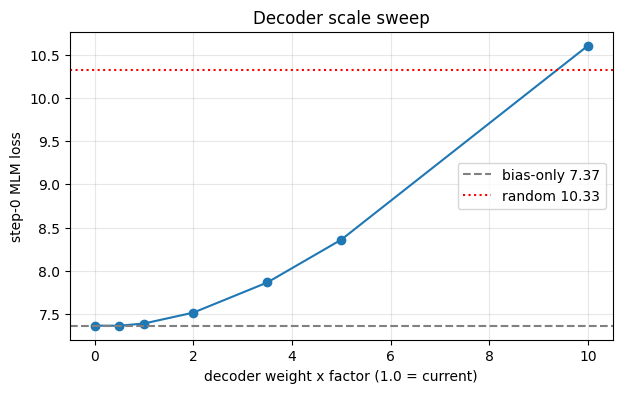

In [8]:
plt.figure(figsize=(7,4))
plt.plot(sweep.factor, sweep.loss, 'o-')
plt.axhline(bias_only, ls='--', c='gray', label=f'bias-only {bias_only:.2f}')
plt.axhline(math.log(VOCAB), ls=':', c='red', label=f'random {math.log(VOCAB):.2f}')
plt.xlabel('decoder weight x factor (1.0 = current)'); plt.ylabel('step-0 MLM loss')
plt.title('Decoder scale sweep'); plt.legend(); plt.grid(alpha=.3); plt.show()

## D. Embedding geometry vs the NeoBERT manifold
Norms across the three spaces, whether the projection **preserves semantic neighborhoods**, and a PCA scatter of
projected Vietnamese tokens inside NeoBERT's cloud.

── Norm audit (row L2) ──
  neobert   : mean 1.206  std 0.254  p5/p95 0.329/1.370
  videberta : mean 3.509  std 0.580  p5/p95 2.159/4.114
  projected : mean 1.218  std 0.038  p5/p95 1.206/1.315
── kNN preservation (k=10, n=500): 0.024 (scrambled) ──
saved -> /content/drive/MyDrive/SALT3/init/videberta_salt_init_v5_globalmap_freqbias/debug_pca_spaces.png


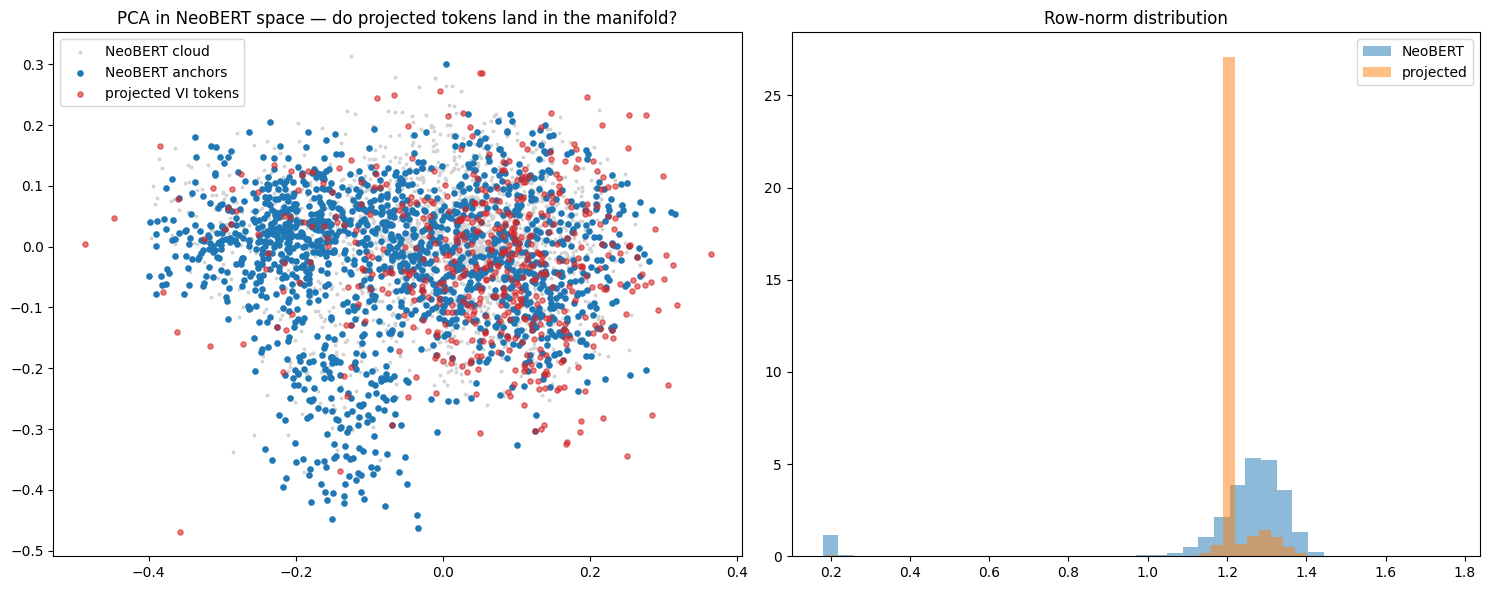

In [9]:
dx.norm_audit(neo_emb, vide_emb, new_emb)

# kNN preservation: ViDeBERTa neighbors vs projected-NeoBERT neighbors
sample_ids = list(new_to_vide.keys())
rng = np.random.default_rng(0)
sample_ids = list(rng.choice(sample_ids, size=min(500, len(sample_ids)), replace=False))
dx.knn_preservation(vide_emb, new_emb, new_to_vide, sample_ids, k=10)

# PCA scatter in NeoBERT space (anchors from the saved csv)
anchor_neo_ids = [neo_vocab[t] for t in ANCHOR_MAP.values() if t in neo_vocab][:1500]
dx.visualize_spaces(neo_emb, new_emb, anchor_neo_ids, sample_ids,
                    save_path=str(NEW_INIT_DIR/'debug_pca_spaces.png'))

## E. Decoder (LM head) geometry
Is the untied head consistent with the embeddings, and does a global linear emb→dec map even exist?

In [10]:
M, resid = fit_embedding_to_decoder_map(neo_emb, neo_dec)
print(f'global emb->dec residual on NeoBERT : {resid:.3f} '
      f'({"linear head exists" if resid<0.7 else "HIGH — tying may be needed"})')
print(f'new decoder row-norm mean : {new_dec.norm(dim=1).mean():.4f}  (NeoBERT {neo_dec.norm(dim=1).mean():.4f})')
print(f'new decoder bias norm     : {new_bias.norm():.2f}  range [{new_bias.min():.2f},{new_bias.max():.2f}]')
emb_dec_cos = F.cosine_similarity(new_emb, new_dec).abs()
print(f'|cos(emb_row, dec_row)| median : {emb_dec_cos.median():.3f}  '
      f'({"untied/independent" if emb_dec_cos.median()<0.9 else "nearly tied"})')

global emb->dec residual on NeoBERT : 0.549 (linear head exists)
new decoder row-norm mean : 0.1320  (NeoBERT 1.3433)
new decoder bias norm     : 2548.64  range [-16.78,-3.28]
|cos(emb_row, dec_row)| median : 0.023  (untied/independent)


## F. Rung 1 — donor-space soundness *(loads FastText, ~7GB RAM)*
Does the **donor's own** embedding geometry carry Vietnamese semantics? kNN overlap vs FastText-vi over full-word
tokens — no projection involved, so a failure here indicts the donor (DeBERTa-v3 trained with RTD may simply lack
semantic embeddings), not the projection math. Gates: **>0.2 usable, <0.05 ≈ chance → swap donor**.


In [11]:
# Rung 1: the donor's OWN geometry vs FastText-vi — no projection involved.
# If this fails, no projection fix can help: the donor never had VI semantics.
if 'ft' not in globals() or ft is None:
    ft = fx.ensure_fasttext(FASTTEXT_BIN)
donor_sound = dx.donor_space_soundness(vide_emb, vide_vocab, ft, n=1000, k=10)

# PhoBERT donor arm — uncomment once that candidate is in play:
# pho_tok = AutoTokenizer.from_pretrained('vinai/phobert-base-v2')
# pho_model = AutoModel.from_pretrained('vinai/phobert-base-v2')
# pho_sound = dx.donor_space_soundness(extract_embedding_weight(pho_model).float().cpu(),
#                                      pho_tok.get_vocab(), ft, n=1000, k=10)


── Donor-space soundness (n=1000, k=10, chance≈0.010) ──
  kNN overlap vs FastText-vi: raw 0.014 | syllable-mean 0.013
  verdict: DONOR BROKEN — ~chance vs FastText; swap donor   (gates: >0.2 usable, <0.05 broken)


## G. Leave-one-out projection test  *(RUN_LOO)*
Ground truth: hide each anchor, project it from the others with the real SALT math, compare to its TRUE NeoBERT
row. High cosine ⇒ math is fine, look elsewhere. Low ⇒ the projection itself is the leak.

── Leave-one-out anchor reconstruction ──
  anchors tested        : 1500
  cosine  mean/median   : 0.341 / 0.286
  cosine  >0.7 fraction : 2.3%   (>0.5: 27.9%)
  norm ratio mean       : 0.372  (1.0 = perfect scale)
  |coef| max  p50/p95   : 0.13 / 0.26  (>>1 = extrapolation)
  verdict               : PROJECTION IS THE LEAK


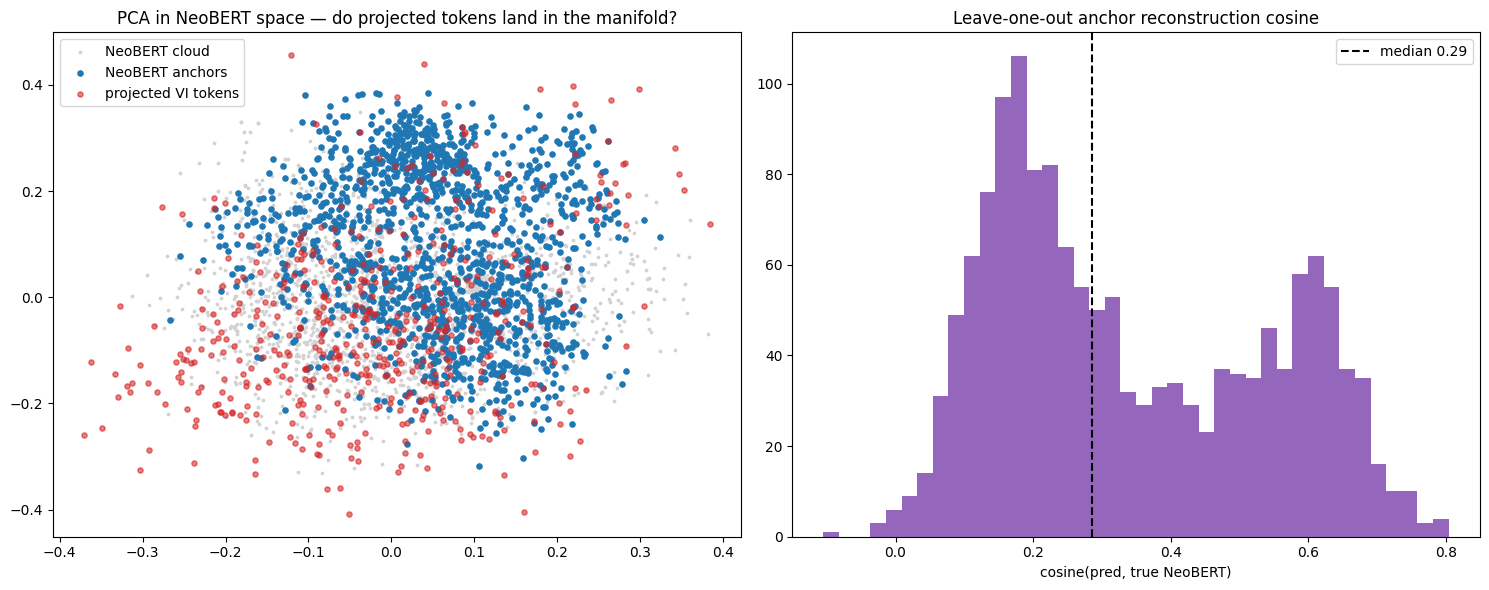

In [12]:
if RUN_LOO:
    if 'ft' not in globals() or ft is None:
        ft = fx.ensure_fasttext(FASTTEXT_BIN)

    anchor_map = {vi: neo for vi, neo in ANCHOR_MAP.items()
                  if vi in vide_vocab and neo in neo_vocab}
    target_vocab = {t: vide_vocab[t] for t in anchor_map}      # vi token -> ViDeBERTa row
    new_to_old   = {i: i for i in vide_vocab.values()}          # identity
    loo = dx.leave_one_out_anchor_error(anchor_map, neo_vocab, target_vocab, new_to_old,
                                        neo_emb, vide_emb, ft, max_anchors=1500)
    dx.visualize_spaces(neo_emb, new_emb, anchor_neo_ids, sample_ids, loo_df=loo)
    ft = None; gc.collect()  # release ~7GB; later sections don't need it
else:
    loo = None
    print('RUN_LOO=False — skipped (set True for the ground-truth projection test).')

## H. Old SALT init compare  *(RUN_OLD_COMPARE)*
Best-effort. Loads whatever checkpoint is in the `SALT` folder, measures its step-0 loss in **this same harness**,
and — if the vocab matches — runs a 2×2 component-swap to localize any gap to embedding / decoder / bias. If you got
14 loss before, this tells us whether that was the init or a load/mismatch artifact.

In [13]:
old_model = old_tok = old_loss = swap_df = None
if RUN_OLD_COMPARE and OLD_SALT_ROOT.exists():
    try:
        old_model, old_tok = fx.load_init_model(str(OLD_SALT_ROOT), device=DEVICE, fallback_tokenizer=new_tok)
        old_loss = fx.masked_lm_loss(old_model, old_tok, EVAL_SENTS, device=DEVICE)
        print(f'\nOLD SALT step-0 loss: {old_loss:.3f} (ppl {math.exp(old_loss):.0f}) '
              f'vs NEW {full_loss:.3f} (ppl {math.exp(full_loss):.0f})')
        if fx.vocab_identical(new_tok, old_tok):
            print('vocab identical -> component-swap ablation:')
            swap_df = fx.component_swap_ablation(new_model, old_model, new_tok, EVAL_SENTS, device=DEVICE)
        else:
            print('vocab DIFFERS -> shared-token cosine instead of swap:')
            sc_df = fx.shared_token_emb_cosine(new_model, new_tok, old_model, old_tok)
            plt.figure(figsize=(7,4)); plt.hist(sc_df.cos, bins=50, color='tab:green')
            plt.title('Shared-token embedding cosine: new vs old SALT'); plt.xlabel('cosine'); plt.show()
        old_sweep = fx.decoder_scale_sweep(old_model, old_tok, EVAL_SENTS, device=DEVICE)
    except Exception as e:
        print('Old SALT compare failed:', repr(e))
else:
    print('RUN_OLD_COMPARE off or folder missing — skipped.')

Loading weights:   0%|          | 0/170 [00:00<?, ?it/s]

[transformers] NeoBERTLMHead LOAD REPORT from: /content/drive/MyDrive/SALT
Key            | Status  | 
---------------+---------+-
decoder.weight | MISSING | 
decoder.bias   | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  ⚠ checkpoint has NO decoder keys -> reconstructed TIED head (decoder=embeddings, bias=0)
  ⚠ no usable tokenizer in folder (ValueError) -> using fallback tokenizer (len 30522 == model vocab)
  loaded SALT: vocab=30522, tok_len=30522

OLD SALT step-0 loss: nan (ppl nan) vs NEW 7.390 (ppl 1621)
vocab identical -> component-swap ablation:
── Component-swap ablation (donor rows into base) ──
  none (base)          loss 7.390  (Δ +0.000)
  +donor embedding     loss 7.382  (Δ -0.009)
  +donor decoder       loss 7.733  (Δ +0.343)
  +donor bias          loss 10.046  (Δ +2.656)
  +donor all           loss 10.755  (Δ +3.365)
  → the single swap with the biggest negative Δ is the component carrying the gap.
── Decoder scale sweep (factor 1.0 = current init, 0 = bias-only) ──
  x0.0   loss nan
  x0.5   loss nan
  x1.0   loss nan
  x2.0   loss nan
  x3.5   loss nan
  x5.0   loss nan
  x10.0  loss nan
Old SALT compare failed: ValueError('Encountered all NA values')


## I. Init bake-off
One table across all init candidates, scored in the same harness — the input to the **init decision gate**. The
decisive metric is `ctx_gain ≥ +0.1` nats (step-0 loss at least 0.1 below the bias-only unigram floor). Register
additional init artifacts in `BAKEOFF_EXTRA` (config cell) as they are produced.


In [14]:
# Bake-off: every candidate scored in the SAME harness — this table is the input to
# the init decision gate (ctx_gain >= +0.1 nats below the bias-only unigram floor).
# Register new init artifacts in BAKEOFF_EXTRA (config cell) as they land.
cands = [('v5_lle (new init)', new_model)]
if old_model is not None:
    cands.append(('old_salt1', (old_model, old_tok)))
cands += list(BAKEOFF_EXTRA)
knn_fns = {'v5_lle (new init)': lambda m: dx.knn_preservation(
    vide_emb, extract_embedding_weight(m).float().cpu(), new_to_vide, sample_ids, k=10)}
bakeoff_df = fx.compare_init_candidates(cands, new_tok, EVAL_SENTS, device=DEVICE, knn_fns=knn_fns)
bakeoff_df



━━ candidate: v5_lle (new init) ━━
── Decoder scale sweep (factor 1.0 = current init, 0 = bias-only) ──
  x0.0   loss 7.366
  x0.5   loss 7.365
  x1.0   loss 7.390
  x2.0   loss 7.516
  x3.5   loss 7.865
  x5.0   loss 8.360
  argmin factor = 0.5 (loss 7.365); bias-only = [7.36566196]
── kNN preservation (k=10, n=500): 0.024 (scrambled) ──

━━ candidate: old_salt1 ━━
── Decoder scale sweep (factor 1.0 = current init, 0 = bias-only) ──
  x0.0   loss nan
  x0.5   loss nan
  x1.0   loss nan
  x2.0   loss nan
  x3.5   loss nan
  x5.0   loss nan

  ⚠ candidate 'old_salt1' failed: ValueError('Encountered all NA values') — NaN row, bake-off continues

── Init bake-off (gate: ctx_gain ≥ +0.100 nats below the bias-only floor) ──
  v5_lle (new init)            loss 7.390  floor 7.366  ctx -0.025 [fail]  argmin x0.5   kNN 0.024  |dec| 0.132
  old_salt1                    loss nan  floor nan  ctx +nan [fail]  argmin xnan   kNN   —    |dec| nan


,candidate,step0_loss,bias_only,ctx_gain,sweep_argmin,knn_preservation,dec_row_norm
0,v5_lle (new init),7.390491,7.365662,-0.024829,0.5,0.0236,0.13197
1,old_salt1,NaN,NaN,NaN,NaN,NaN,NaN


## J. Verdict

In [15]:
print('='*64); print('SALT3 INIT DEBUG — VERDICT'); print('='*64)
print(f'new init step-0 loss : {full_loss:.3f}  (bias-only {bias_only:.3f}, random {math.log(VOCAB):.3f})')
ds = donor_sound if 'donor_sound' in globals() else None
if ds:
    b = max(ds['overlap_raw'], ds['overlap_syllable'])
    print(f'0. donor soundness   : {b:.3f}  -> '
          + ('donor OK — geometry carries VI semantics' if b > 0.2
             else 'DONOR BROKEN — PhoBERT arm is the priority' if b < 0.05
             else 'weak donor — projection must be near-lossless'))
else:
    print('0. donor soundness   : skipped (run section F)')
ctx = bias_only - full_loss
print(f'1. context vs prior  : {ctx:+.3f} nats  -> '
      + ('embeddings/encoder ARE adding context' if ctx>0.05 else 'SITTING ON THE UNIGRAM FLOOR (no context)'))
best = sweep.loc[sweep.loss.idxmin()]
print(f'2. best decoder scale: x{best.factor} (loss {best.loss:.3f})  -> '
      + ('decoder-STARVED, raise DECODER_WEIGHT_SCALE' if best.factor>1
         else 'decoder hurts when louder — geometry/prior issue' if best.factor<1 else 'current scale ~optimal'))
if loo is not None:
    m = loo.dropna(subset=['cos']).cos.median()
    print(f'3. LOO recon cosine  : {m:.3f}  -> ' + ('MATH OK, look at forward/decoder' if m>0.7 else 'PROJECTION IS THE LEAK' if m<0.5 else 'borderline'))
else:
    print('3. LOO               : skipped (RUN_LOO=False)')
if old_loss is not None:
    print(f'4. old SALT vs new   : {old_loss:.3f} vs {full_loss:.3f}  -> '
          + ('old is BETTER — diff it' if old_loss<full_loss-0.1 else 'old NOT better (memory/old-load artifact)'))
    if swap_df is not None:
        g = swap_df.iloc[1:4].copy(); g['d']=g.loss-swap_df.iloc[0].loss
        worst = g.loc[g.d.idxmin()]
        print(f'   component carrying gap: {worst.swapped} (Δ {worst.d:+.3f})')
else:
    print('4. old SALT compare  : skipped')
print('='*64)

SALT3 INIT DEBUG — VERDICT
new init step-0 loss : 7.390  (bias-only 7.366, random 10.326)
0. donor soundness   : 0.014  -> DONOR BROKEN — PhoBERT arm is the priority
1. context vs prior  : -0.025 nats  -> SITTING ON THE UNIGRAM FLOOR (no context)
2. best decoder scale: x0.5 (loss 7.365)  -> decoder hurts when louder — geometry/prior issue
3. LOO recon cosine  : 0.286  -> PROJECTION IS THE LEAK
4. old SALT vs new   : nan vs 7.390  -> old NOT better (memory/old-load artifact)
   component carrying gap: +donor embedding (Δ -0.009)
